# Outlier visualization — the five criteria

Exploratory views of the **894-sample** peak dataset along the five outlier criteria used to screen it
*before* the train/val/test split:

1. **Peak-label** — `ex_max`, `em_max`, Stokes shift (`em−ex`), modified z-score (median/MAD) |z|>3.5
2. **Sequence isolation** — nearest-neighbor 4-mer cosine similarity to all other sequences (< 0.10)
3. **Embedding anomaly** — IsolationForest on PCA-reduced mean-pooled ESM-2 embeddings (5% contamination)
4. **Length** — modified z-score on sequence length (|z|>3.5)
5. **Non-canonical chromophore** — FPbase `cofactor` field (biliverdin / flavin / bilirubin / …)

Nothing is modified on disk; this only reads `training_data/` and the FPbase protein export.

## 0. Setup + compute all five criteria

In [1]:
import csv, json, numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as cossim
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception: HAVE_APC=False
import matplotlib.pyplot as plt
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#9a9a9a","wish":"#5088c5","aster":"#7a5ea8","dragon":"#b23b3b","lime":"#97c800","tangerine":"#ff8c42"}.get(k,"#333")
C=_C()
TD="training_data"
rows=list(csv.DictReader(open(f"{TD}/peak_assignments.csv"))); N=len(rows)
peaks=np.load(f"{TD}/peaks.npy").astype(np.float32); EX=peaks[:,0]; EM=peaks[:,1]; STK=EM-EX
names=[r["name"] for r in rows]; slug=[r["slug"] for r in rows]; LEN=np.array([int(r["seq_len"]) for r in rows])
seqs=[None]*N; h=None
for line in open(f"{TD}/sequences.fasta"):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
prot=json.load(open("../fpbase-extractor/fpbase_output/fpbase_proteins.json"))
cofmap={p["slug"]:(p.get("cofactor") or "") for p in prot}
COF=np.array([cofmap.get(s,"") for s in slug])

def mz(x):                                            # modified (robust) z-score
    med=np.median(x); mad=np.median(np.abs(x-med)) or 1e-9; return 0.6745*(x-med)/mad
z_ex,z_em,z_st,z_len=mz(EX),mz(EM),mz(STK),mz(LEN)

# (1) peak-label  (2) sequence isolation  (3) embedding  (4) length  (5) cofactor
f_peak=(np.abs(z_ex)>3.5)|(np.abs(z_em)>3.5)|(np.abs(z_st)>3.5)
Xk=CountVectorizer(analyzer="char",ngram_range=(4,4)).fit_transform(seqs)
Sk=cossim(Xk); np.fill_diagonal(Sk,-1); NN=Sk.max(1); f_seq=NN<0.10
Hh=np.load(f"{TD}/esm_residue_fp16.npy"); Ls=np.load(f"{TD}/esm_residue_len.npy")
emb=np.stack([Hh[i,:Ls[i]].astype(np.float32).mean(0) for i in range(N)])
Zpca=PCA(50,random_state=0).fit_transform((emb-emb.mean(0))/(emb.std(0)+1e-6))
iso=IsolationForest(contamination=0.05,random_state=0).fit(Zpca)
ISO=-iso.score_samples(Zpca); f_emb=iso.predict(Zpca)==-1
f_len=np.abs(z_len)>3.5
f_cof=np.array([c.strip().lower() not in ("","none") for c in COF])

CRIT=["peak","seq-iso","embed","length","cofactor"]
FLAGS=np.stack([f_peak,f_seq,f_emb,f_len,f_cof]).T.astype(int)        # (N,5)
NCRIT=FLAGS.sum(1)
TSNE2=TSNE(2,random_state=0,perplexity=30,init="pca").fit_transform(Zpca)
COFCOL={"":C.gray,"BV":C.dragon,"FL":C.amber,"BR":C.tangerine,"PC":C.aegean,"RL":C.aster}
print(f"N={N} | flagged >=1: {(NCRIT>=1).sum()}  >=2: {(NCRIT>=2).sum()}  >=3: {(NCRIT>=3).sum()}")
print("per-criterion counts:", {c:int(FLAGS[:,j].sum()) for j,c in enumerate(CRIT)})

N=894 | flagged >=1: 227  >=2: 80  >=3: 53
per-criterion counts: {'peak': 173, 'seq-iso': 8, 'embed': 45, 'length': 90, 'cofactor': 59}


## 1. Peak-label criterion — the spectral landscape

Every sample on the `ex_max` vs `em_max` plane (the FP "spectral map"), colored by chromophore class.
Points ringed in black are flagged by the peak-label z-score. Marginal histograms show the `ex_max`,
`em_max` and Stokes-shift distributions with the |z|>3.5 thresholds shaded.

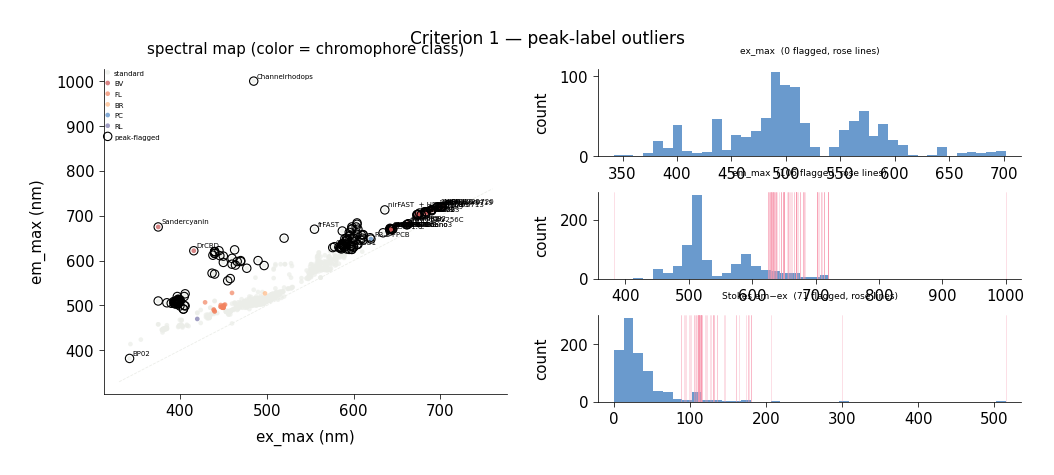

In [2]:
fig=plt.figure(figsize=(14,5.5))
ax=fig.add_axes([0.06,0.1,0.40,0.82])
for cf in ["","BV","FL","BR","PC","RL"]:
    m=COF==cf
    if m.any(): ax.scatter(EX[m],EM[m],s=22,c=COFCOL[cf],alpha=0.7,edgecolor="none",label=(cf or "standard"))
ax.scatter(EX[f_peak],EM[f_peak],s=70,facecolors="none",edgecolors="k",lw=1.1,label="peak-flagged")
lo,hi=330,760; ax.plot([lo,hi],[lo,hi],ls="--",c=C.gray,lw=0.8)
for i in np.where(f_peak&(NCRIT>=3))[0]: ax.annotate(names[i][:14],(EX[i],EM[i]),fontsize=7,xytext=(3,3),textcoords="offset points")
ax.set_xlabel("ex_max (nm)"); ax.set_ylabel("em_max (nm)"); ax.set_title("spectral map (color = chromophore class)"); ax.legend(fontsize=7,loc="upper left")
for k,(arr,lab) in enumerate([(EX,"ex_max"),(EM,"em_max"),(STK,"Stokes em−ex")]):
    a=fig.add_axes([0.55,0.70-0.31*k,0.42,0.22])
    a.hist(arr,bins=40,color=C.aegean,alpha=0.85)
    z=mz(arr); out=arr[np.abs(z)>3.5]
    for v in out: a.axvline(v,color=C.rose,lw=0.6,alpha=0.5)
    a.set_ylabel("count"); a.set_title(f"{lab}  ({np.sum(np.abs(z)>3.5)} flagged, rose lines)",fontsize=9)
plt.suptitle("Criterion 1 — peak-label outliers",y=1.02); plt.show()

## 2. Sequence-isolation criterion

Distribution of each sample's **nearest-neighbor 4-mer cosine similarity** to all other sequences. The low
tail (< 0.10) are proteins with no relative in the dataset — unlearnable from sequence. They are listed.

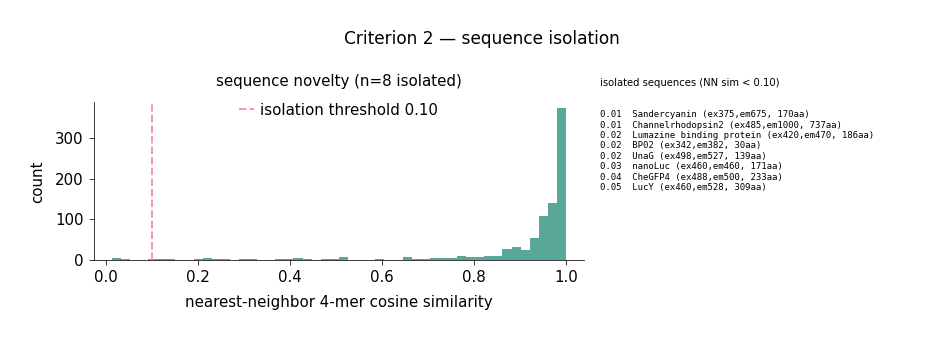

In [3]:
fig,ax=plt.subplots(1,2,figsize=(13,4.2),gridspec_kw={"width_ratios":[2,1.3]})
ax[0].hist(NN,bins=50,color=C.seaweed,alpha=0.85); ax[0].axvline(0.10,color=C.rose,ls="--",label="isolation threshold 0.10")
ax[0].set_xlabel("nearest-neighbor 4-mer cosine similarity"); ax[0].set_ylabel("count")
ax[0].set_title(f"sequence novelty (n={f_seq.sum()} isolated)"); ax[0].legend()
iso_idx=np.where(f_seq)[0][np.argsort(NN[f_seq])]
ax[1].axis("off"); ax[1].set_title("isolated sequences (NN sim < 0.10)",fontsize=10,loc="left")
txt="\n".join(f"{NN[i]:.2f}  {names[i][:26]} (ex{EX[i]:.0f},em{EM[i]:.0f}, {LEN[i]}aa)" for i in iso_idx)
ax[1].text(0,0.95,txt,va="top",ha="left",fontsize=9,family="monospace")
plt.suptitle("Criterion 2 — sequence isolation"); plt.tight_layout(); plt.show()

## 3. Embedding-anomaly criterion

2-D t-SNE of mean-pooled ESM-2 embeddings (via 50-D PCA). **Left:** colored by IsolationForest anomaly
score (flagged points ringed). **Right:** colored by chromophore class — the cofactor families (biliverdin,
flavin) form their own islands at the periphery, which is *why* they read as embedding outliers.

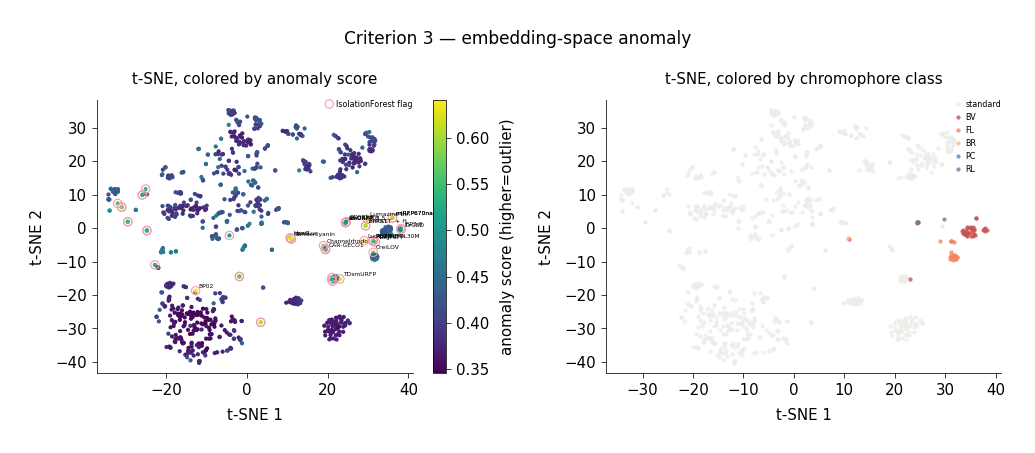

In [4]:
fig,ax=plt.subplots(1,2,figsize=(14,5.8))
sc=ax[0].scatter(TSNE2[:,0],TSNE2[:,1],c=ISO,s=18,cmap="viridis")
ax[0].scatter(TSNE2[f_emb,0],TSNE2[f_emb,1],s=70,facecolors="none",edgecolors=C.rose,lw=1.1,label="IsolationForest flag")
for i in np.where(f_emb&(NCRIT>=3))[0]: ax[0].annotate(names[i][:12],(TSNE2[i,0],TSNE2[i,1]),fontsize=6,xytext=(3,3),textcoords="offset points")
fig.colorbar(sc,ax=ax[0],label="anomaly score (higher=outlier)"); ax[0].set_title("t-SNE, colored by anomaly score"); ax[0].legend(fontsize=8)
for cf in ["","BV","FL","BR","PC","RL"]:
    m=COF==cf
    if m.any(): ax[1].scatter(TSNE2[m,0],TSNE2[m,1],s=18,c=COFCOL[cf],alpha=0.8,label=(cf or "standard"))
ax[1].set_title("t-SNE, colored by chromophore class"); ax[1].legend(fontsize=8)
for a in ax: a.set_xlabel("t-SNE 1"); a.set_ylabel("t-SNE 2")
plt.suptitle("Criterion 3 — embedding-space anomaly"); plt.tight_layout(); plt.show()

## 4. Length criterion

Sequence-length distribution with the |z|>3.5 threshold; and length vs `em_max` (long sequences are mostly
the biliverdin phytochrome-derived NIR proteins and indicator fusions).

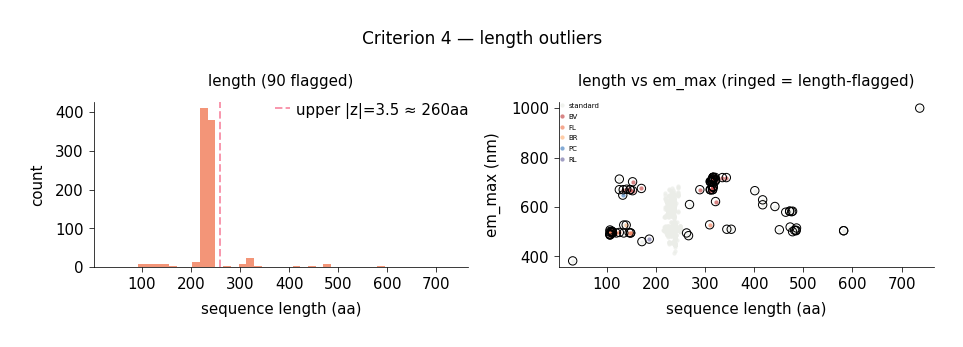

In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,4.3))
ax[0].hist(LEN,bins=45,color=C.amber,alpha=0.85)
thi=np.median(LEN)+(3.5/0.6745)*(np.median(np.abs(LEN-np.median(LEN))) or 1)
ax[0].axvline(thi,color=C.rose,ls="--",label=f"upper |z|=3.5 ≈ {thi:.0f}aa")
ax[0].set_xlabel("sequence length (aa)"); ax[0].set_ylabel("count"); ax[0].set_title(f"length ({f_len.sum()} flagged)"); ax[0].legend()
for cf in ["","BV","FL","BR","PC","RL"]:
    m=COF==cf
    if m.any(): ax[1].scatter(LEN[m],EM[m],s=18,c=COFCOL[cf],alpha=0.7,label=(cf or "standard"))
ax[1].scatter(LEN[f_len],EM[f_len],s=70,facecolors="none",edgecolors="k",lw=1.0)
ax[1].set_xlabel("sequence length (aa)"); ax[1].set_ylabel("em_max (nm)"); ax[1].set_title("length vs em_max (ringed = length-flagged)"); ax[1].legend(fontsize=7)
plt.suptitle("Criterion 4 — length outliers"); plt.tight_layout(); plt.show()

## 5. Non-canonical chromophore criterion

Counts per FPbase `cofactor` class, and the `em_max` distribution within each — biliverdin (BV) pushes far-red,
flavin (FL) sits cyan-green. These peaks are set by a *bound* cofactor, not a GFP-type autocatalytic chromophore.

/var/folders/f4/yby3h8gx3h9btcfh8c1ff7v40000gn/T/ipykernel_70976/3312105085.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  parts=ax[1].boxplot(data,labels=dl,vert=True,showfliers=True,patch_artist=True)


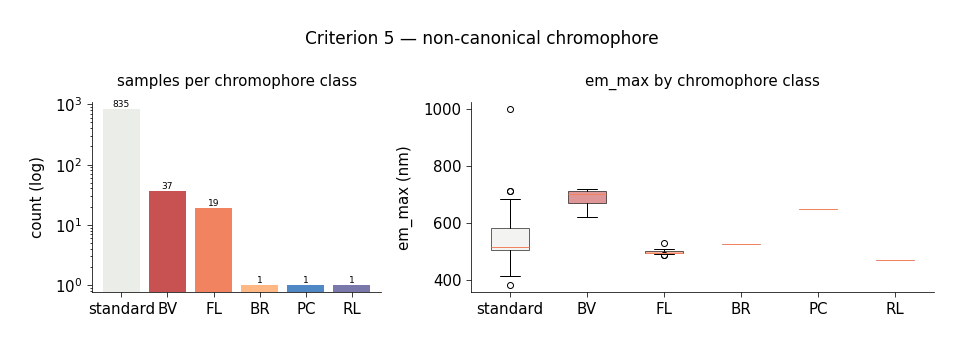

In [6]:
classes=["","BV","FL","BR","PC","RL"]; labs=["standard","BV","FL","BR","PC","RL"]
cnt=[int((COF==c).sum()) for c in classes]
fig,ax=plt.subplots(1,2,figsize=(13,4.3),gridspec_kw={"width_ratios":[1,1.6]})
ax[0].bar(labs,cnt,color=[COFCOL[c] for c in classes]); ax[0].set_yscale("log"); ax[0].set_ylabel("count (log)")
for i,v in enumerate(cnt): ax[0].text(i,v,str(v),ha="center",va="bottom",fontsize=9)
ax[0].set_title("samples per chromophore class")
data=[EM[COF==c] for c in classes if (COF==c).any()]; dl=[l for c,l in zip(classes,labs) if (COF==c).any()]
parts=ax[1].boxplot(data,labels=dl,vert=True,showfliers=True,patch_artist=True)
for pc,c in zip(parts["boxes"],[c for c in classes if (COF==c).any()]): pc.set_facecolor(COFCOL[c]); pc.set_alpha(0.6)
ax[1].set_ylabel("em_max (nm)"); ax[1].set_title("em_max by chromophore class")
plt.suptitle("Criterion 5 — non-canonical chromophore"); plt.tight_layout(); plt.show()

## 6. Consensus — how the criteria co-fire

How many criteria each sample trips, and a binary heatmap of every sample flagged by **≥2 criteria**
(rows = proteins, columns = the five criteria). Bottom: the full ≥2-criteria table.

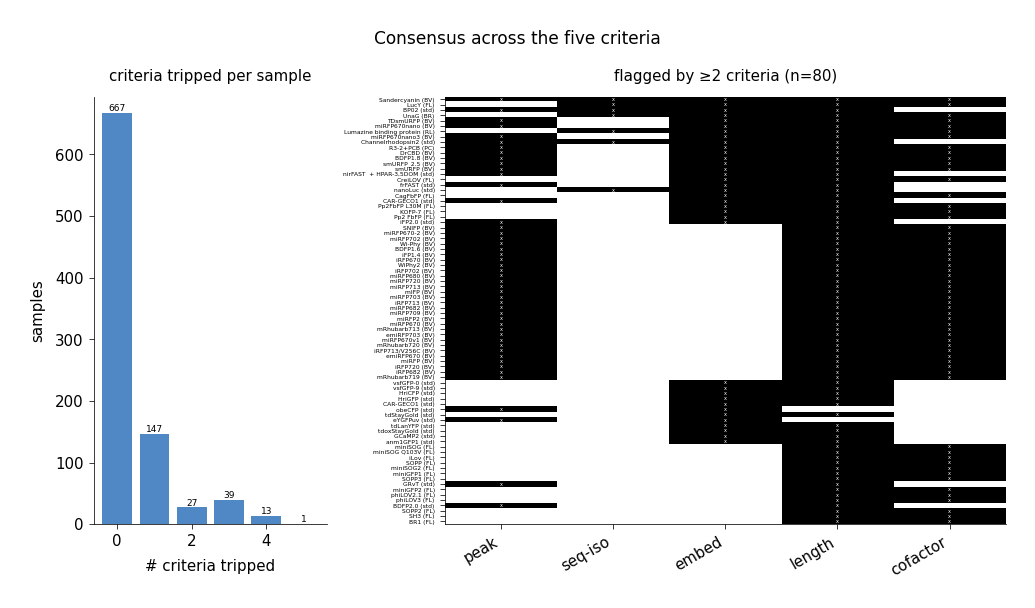

name                       cof   ex   em  stk  len    NN   iso  criteria
Sandercyanin                BV  375  675  300  170  0.01  0.62  peak,seq-iso,embed,length,cofactor
LucY                        FL  460  528   68  309  0.05  0.64  seq-iso,embed,length,cofactor
BP02                         -  342  382   40   30  0.02  0.64  peak,seq-iso,embed,length
UnaG                        BR  498  527   29  139  0.02  0.63  seq-iso,embed,length,cofactor
TDsmURFP                    BV  642  670   28  289  0.98  0.62  peak,embed,length,cofactor
miRFP670nano                BV  645  670   25  147  0.67  0.62  peak,embed,length,cofactor
Lumazine binding protein    RL  420  470   50  186  0.02  0.61  seq-iso,embed,length,cofactor
miRFP670nano3               BV  645  670   25  147  0.67  0.61  peak,embed,length,cofactor
Channelrhodopsin2            -  485 1000  515  737  0.01  0.60  peak,seq-iso,embed,length
R3-2+PCB                    PC  620  648   28  132  0.57  0.52  peak,embed,length,cofactor
Dr

In [7]:
fig,ax=plt.subplots(1,2,figsize=(14,8),gridspec_kw={"width_ratios":[1,2.4]})
vals,c=np.unique(NCRIT,return_counts=True)
ax[0].bar(vals,c,color=C.aegean); ax[0].set_xlabel("# criteria tripped"); ax[0].set_ylabel("samples")
for v,cc in zip(vals,c): ax[0].text(v,cc,str(cc),ha="center",va="bottom",fontsize=9)
ax[0].set_title("criteria tripped per sample")
sel=np.where(NCRIT>=2)[0]; sel=sel[np.argsort(-(NCRIT[sel]*10+ISO[sel]))]
im=ax[1].imshow(FLAGS[sel],aspect="auto",cmap="Greys",vmin=0,vmax=1)
ax[1].set_xticks(range(5)); ax[1].set_xticklabels(CRIT,rotation=30,ha="right")
ax[1].set_yticks(range(len(sel))); ax[1].set_yticklabels([f"{names[i][:24]} ({COF[i] or 'std'})" for i in sel],fontsize=6)
ax[1].set_title(f"flagged by ≥2 criteria (n={len(sel)})")
for (yy,xx),v in np.ndenumerate(FLAGS[sel]):
    if v: ax[1].text(xx,yy,"x",ha="center",va="center",color="white",fontsize=5)
plt.suptitle("Consensus across the five criteria"); plt.tight_layout(); plt.show()

print(f"{'name':26s}{'cof':>4}{'ex':>5}{'em':>5}{'stk':>5}{'len':>5}{'NN':>6}{'iso':>6}  criteria")
for i in sel:
    tags=",".join(CRIT[j] for j in range(5) if FLAGS[i,j])
    print(f"{names[i][:26]:26s}{(COF[i] or '-'):>4}{EX[i]:5.0f}{EM[i]:5.0f}{STK[i]:5.0f}{LEN[i]:5d}{NN[i]:6.2f}{ISO[i]:6.2f}  {tags}")

## Notes
- All criteria are intrinsic to the data (labels, sequence, embedding, metadata) — no model is trained, so this
  can be run **before** the split to decide what to drop, down-weight, or stratify.
- `length` is the least specific criterion (it largely co-fires with `cofactor`); `cofactor` and `seq-iso` are the
  most principled. `peak-label` flags the whole legitimate far-red regime, so treat it as a *regime* marker.
- See the per-class breakdown: 835/894 samples are standard autocatalytic FPs; the rest are cofactor-bound.